In [ ]:
from SRC.pairs_trading import PairsBacktest
from SRC.data_loader import DataLoader
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [ ]:
# Initialize the tickers and years
tickers = ['GOOGL', 'NVDA', 'MSFT', 'META', 'TSLA']
years = 170/365

## Monte Carlo Simulation for Z-Score Optimization

In [ ]:
%%capture

# Initialize the z-scores to test
z_scores_to_test = np.arange(-2.5, 2.6, 0.1)

simulation_results = []

for z in z_scores_to_test:
    try:
        # Initialize backtester with current z-score
        backtester_sim = PairsBacktest(years, tickers, lookback_window=20, entry_z=z)

        # Run the backtest and compute metrics
        metrics = backtester_sim.compute_metrics()

        # Extract relevant metrics
        sharpe_ratio = float(metrics[metrics['Metric'] == 'Sharpe Ratio']['Value'].iloc[0])
        alpha_str = metrics[metrics['Metric'] == 'Alpha']['Value'].iloc[0]
        alpha = float(alpha_str.replace('%', ''))  # Convert percentage string to float
        total_return_str = metrics[metrics['Metric'] == 'Total Return']['Value'].iloc[0]
        total_return = float(total_return_str.replace('%', '')) # Convert percentage string to float

        simulation_results.append({
            'Z_Score': z,
            'Sharpe Ratio': sharpe_ratio,
            'Alpha (%)': alpha,
            'Total Return (%)': total_return
        })
    except Exception as e:
        print(f"Skipping Z-Score {z} due to error: {e}")
        continue

simulation_df = pd.DataFrame(simulation_results)

[*********************100%***********************]  5 of 5 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  5 of 5 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  5 of 5 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  5 of 5 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  5 of 5 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  5 of 5 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  5 of 5 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%********

,Z_Score,Sharpe Ratio,Alpha (%),Total Return (%)
0,-2.5,-0.45144,-13.33725,-9.60
1,-2.4,-0.28849,-6.87400,-6.97
2,-2.3,-0.28849,-6.87400,-6.95
3,-2.2,-0.28849,-6.87400,-6.92
4,-2.1,-0.28849,-6.87400,-6.92


In [ ]:
# Identify the optimal z-score based on the maximum Sharpe Ratio
opt_z_score = simulation_df[simulation_df['Sharpe Ratio'] == simulation_df['Sharpe Ratio'].max()].iloc[0, :1][0]

# Run Simulation

In [ ]:
%%capture

# Initialize the backtester
backtester = PairsBacktest(years, tickers, lookback_window=20, entry_z=opt_z_score)
ticker_a = loader.ticker_a
ticker_b = loader.ticker_b
results = backtester.compute_metrics()


# Results

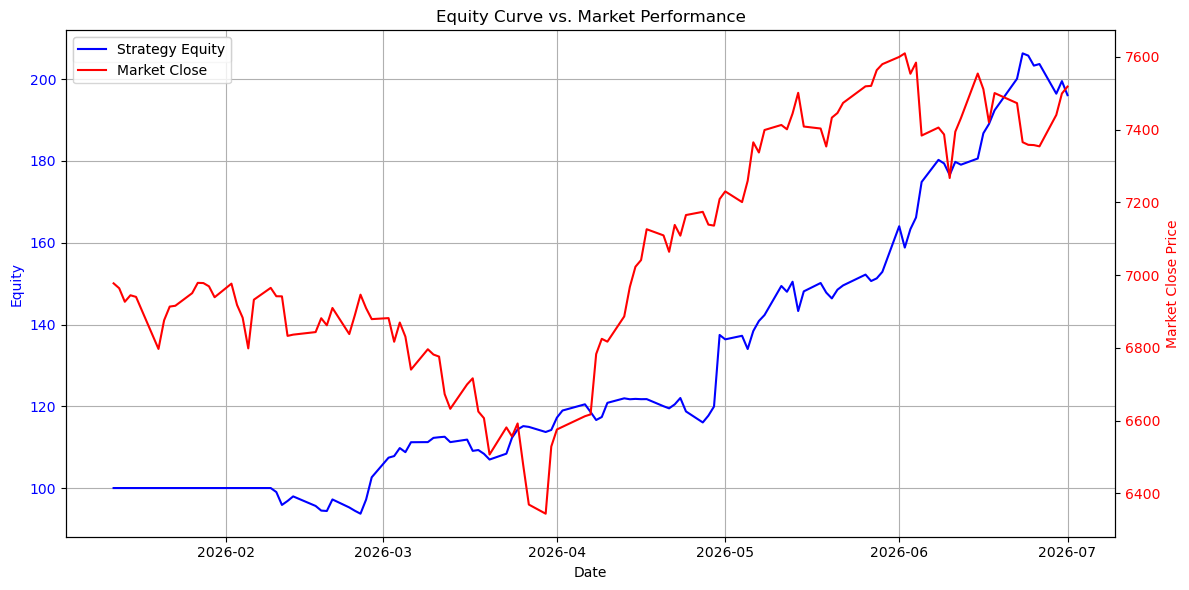

The tickers with the highest correlation, and the ones used in the pairs-trading strategy were NVDA and GOOGL. This strategy used a z-score level of -0.09999999999999787.
             Metric       Value
0      Sharpe Ratio     4.05002
1             Alpha  160.06679%
2      Total Return      96.09%
3      Max Drawdown      -6.28%
4        Start Date  2026-01-12
5          End Date  2026-07-01
6  Starting Capital     $100.00
7    Ending Capital     $196.09
8    Capital Gained      $96.09
9      Total Trades          98


In [ ]:
# Plotting the Equity Curve and Market Performance
fig, ax1 = plt.subplots(figsize=(12, 6))

# Plot Equity Curve on primary y-axis
sns.lineplot(x=backtester.data.index, y=backtester.data['Equity'], ax=ax1, color='blue', label='Strategy Equity')
ax1.set_xlabel('Date')
ax1.set_ylabel('Equity', color='blue')
ax1.tick_params(axis='y', labelcolor='blue')
ax1.grid(True)

# Create a second y-axis for Market Data
ax2 = ax1.twinx()
sns.lineplot(x=backtester.market_data.index, y=backtester.market_data['Close'].squeeze(), ax=ax2, color='red', label='Market Close')
ax2.set_ylabel('Market Close Price', color='red')
ax2.tick_params(axis='y', labelcolor='red')

plt.title('Equity Curve vs. Market Performance')

# Add legends for both axes
lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax2.legend(lines + lines2, labels + labels2, loc='upper left')

plt.tight_layout()
plt.show()

print(f"The tickers with the highest correlation, and the ones used in the pairs-trading strategy were {ticker_a} and {ticker_b}. This strategy used a z-score level of {backtester.entry_z}.")
print(results)